# IEEE-CIS Fraud Detection: Exploratory Data Analysis

**Goal:** Understand the data and identify key fraud patterns

**Deliverable:** 5-7 actionable insights for feature engineering and modeling

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from tabulate import tabulate

from utils import disp_columns, column_distributions

# Settings for notebook
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')

## 1. Load Data

In [4]:
# Load transaction data
train_txn = pd.read_csv(DATA_DIR / 'train_transaction.csv')
train_id = pd.read_csv(DATA_DIR / 'train_identity.csv')

print(f"Transaction data: {train_txn.shape[0]:,} rows, {train_txn.shape[1]} columns")
print(f"Identity data: {train_id.shape[0]:,} rows, {train_id.shape[1]} columns")

Transaction data: 590,540 rows, 394 columns
Identity data: 144,233 rows, 41 columns


In [5]:
# Inspect columns
disp_columns(train_txn, title="train_txn dataframe columns")
disp_columns(train_id, title = "train_id dataframe columns")

┌─────────────────────────────┐
│ train_txn dataframe columns │
│ ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾ │
│ - TransactionID: int64      │
│ - isFraud: int64            │
│ - TransactionDT: int64      │
│ - TransactionAmt: float64   │
│ - ProductCD: object         │
│ - card<N>                   │
│   - N = 1: int64            │
│   - N = 2-3, 5: float64     │
│   - N = 4, 6: object        │
│ - addr<1-2>: float64        │
│ - dist<1-2>: float64        │
│ - P_emaildomain: object     │
│ - R_emaildomain: object     │
│ - C<1-14>: float64          │
│ - D<1-15>: float64          │
│ - M<1-9>: object            │
│ - V<1-339>: float64         │
└─────────────────────────────┘

┌────────────────────────────────────────────────┐
│ train_id dataframe columns                     │
│ ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾                     │
│ - TransactionID: int64                         │
│ - id_<N>                                       │
│   - N = 1-11, 13-14, 17-22, 24-26, 32: float64 │
│   - N = 12, 15-16, 

## 2. Identity data overview

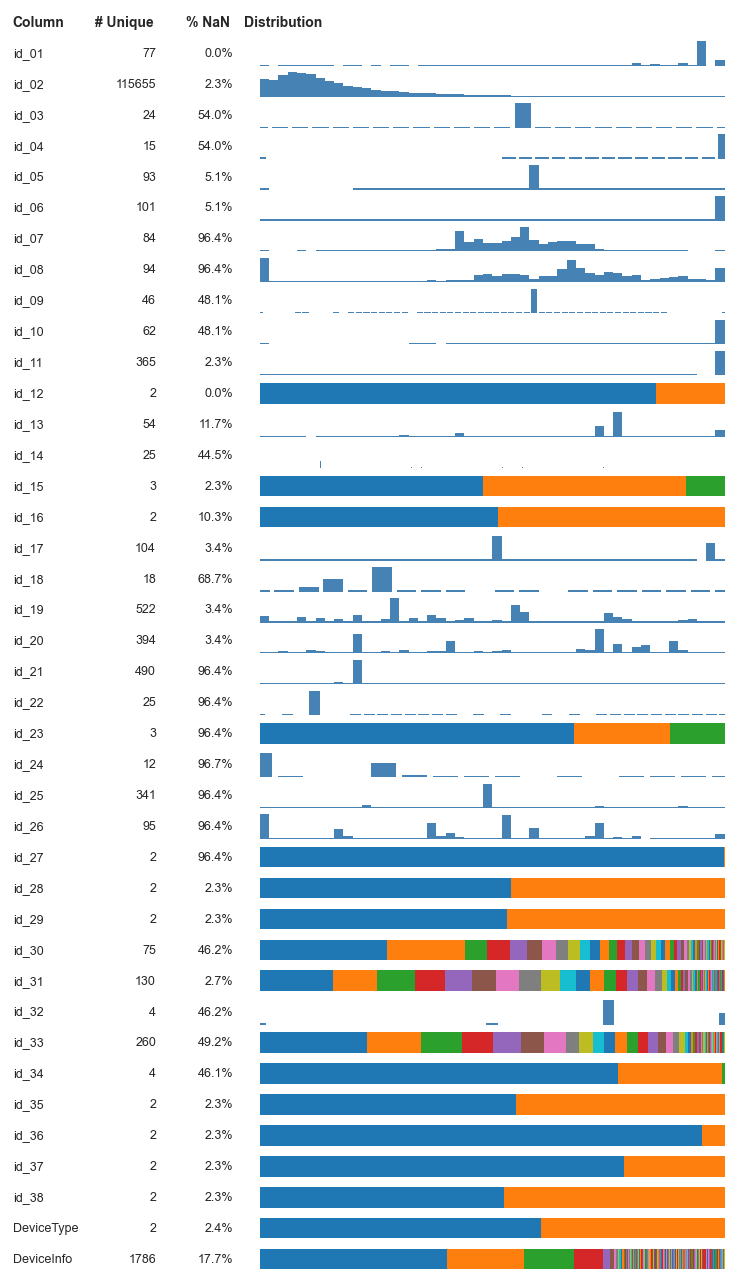

In [6]:
# A look at the distribution of each column

train_id_column_distributions = column_distributions(
    train_id, exclude_cols=['TransactionID', 'isFraud']
)
train_id_column_distributions.savefig(FIG_DIR / 'EDA_identity_column_distributions.png')

In [7]:
# Many of the numeric "id" columns look categorical
# These would be best encoded as categorical features rather than numeric
# 
# E.g. id_32 value counts:
#     +---------+---------+
#     |   value |   count |
#     |---------+---------|
#     |      24 |   53071 |
#     |      32 |   24428 |
#     |      16 |      81 |
#     |       0 |       6 |
#     +---------+---------+
# 
# id_32 only has 4 unique values: 0, 16, 24 and 32. 
# Which probably represent some sort of categorical feature.
# 
# id_02, id_07 and id_08 look like the only numeric features with a 
# "natural-looking" distribution.
# 
# All other numeric features have a few "peaks" — probably best suited for 
# frequency encoding.


print("E.g. id_32 value counts:")
print(
    tabulate(pd.DataFrame(train_id['id_32'].value_counts()), 
    headers=["value", "count"],
    tablefmt="psql"
    )
)
print()

numeric_id_cols = [
    _col for _col, _type in train_id.dtypes.items()
    if _type != "object" and _col != 'TransactionID'
]

# Candidates for label/one-hot encoding
id_label_cols = ["id_32"]
print("Candidates for label/one-hot encoding:", id_label_cols)

# Candidates for frequency encoding:
id_freq_cols = list(set(numeric_id_cols) - set(id_label_cols) - {"id_02", "id_07", "id_08"})
print("Candidates for frequency encoding:", id_freq_cols)

E.g. id_32 value counts:
+---------+---------+
|   value |   count |
|---------+---------|
|      24 |   53071 |
|      32 |   24428 |
|      16 |      81 |
|       0 |       6 |
+---------+---------+

Candidates for label/one-hot encoding: ['id_32']
Candidates for frequency encoding: ['id_25', 'id_11', 'id_20', 'id_14', 'id_10', 'id_19', 'id_13', 'id_22', 'id_21', 'id_04', 'id_18', 'id_01', 'id_26', 'id_24', 'id_06', 'id_05', 'id_17', 'id_03', 'id_09']


In [8]:
missing_ids = set(train_txn['TransactionID']) - set(train_id['TransactionID'])
print(f"{len(missing_ids)} missing IDs in transaction data")

missing_transactions = set(train_id['TransactionID']) - set(train_txn['TransactionID'])
print(f"{len(missing_transactions)} missing transactions in identity data")

446307 missing IDs in transaction data
0 missing transactions in identity data


In [9]:
# Join dataframes to add "isFraud" column to train_id

# Since there are no rows in the train_id dataframe that are not in train_txn,
# we can do a left join and replace the original dataframe
train_id = pd.merge(
    left=train_id,
    right=train_txn[['TransactionID', 'isFraud']],
    how='left',
    on='TransactionID'
)

# We'll also add a "hasID" column to train_txn indicate whether the transaction has an ID
train_txn['hasID'] = train_txn['TransactionID'].isin(train_id['TransactionID'])

Fraud rate: 3.50%
Fraud transactions: 20,663
Legitimate transactions: 569,877


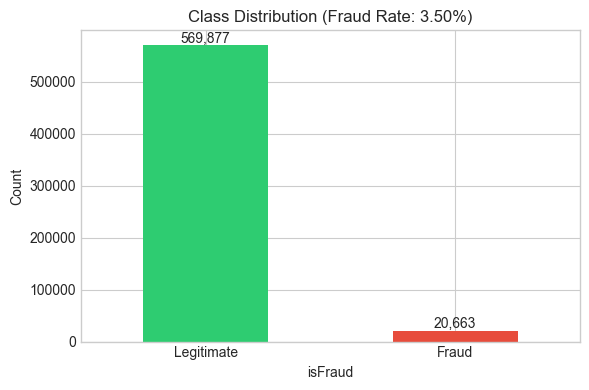

In [10]:
fraud_rate = train_txn['isFraud'].mean()

print(f"Fraud rate: {fraud_rate:.2%}")
print(f"Fraud transactions: {train_txn['isFraud'].sum():,}")
print(f"Legitimate transactions: {(train_txn['isFraud'] == 0).sum():,}")

# Visualize class imbalance
fig, ax = plt.subplots(figsize=(6, 4))
train_txn['isFraud'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
ax.set_ylabel('Count')
ax.set_title(f'Class Distribution (Fraud Rate: {fraud_rate:.2%})')
for i, v in enumerate(train_txn['isFraud'].value_counts()):
    ax.text(i, v + 5000, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

## 3. Data Overview

In [11]:
# Missing values analysis
missing = train_txn.isnull().sum()
missing_pct = (missing / len(train_txn) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)} / {len(train_txn.columns)}")
print(f"\nTop 20 columns by missing %:")
missing_df.head(20)

Columns with missing values: 374 / 395

Top 20 columns by missing %:


,missing_count,missing_pct
dist2,552913,93.63
D7,551623,93.41
D13,528588,89.51
D14,528353,89.47
D12,525823,89.04
D6,517353,87.61
D9,515614,87.31
D8,515614,87.31
V153,508595,86.12
V160,508589,86.12


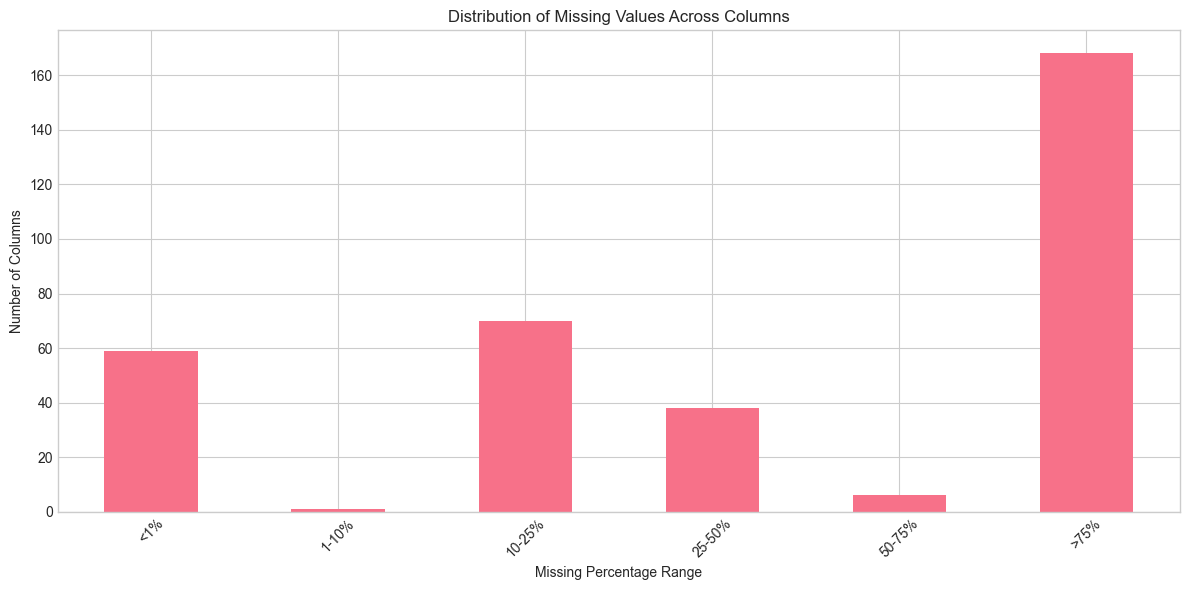

In [12]:
# Visualize missing value pattern
fig, ax = plt.subplots(figsize=(12, 6))
missing_ranges = pd.cut(
    missing_pct, 
    bins=[0, 1, 10, 25, 50, 75, 100], 
    labels=['<1%', '1-10%', '10-25%', '25-50%', '50-75%', '>75%']
)
missing_ranges.value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('Missing Percentage Range')
ax.set_ylabel('Number of Columns')
ax.set_title('Distribution of Missing Values Across Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Transaction Amount Analysis

In [13]:
# Transaction amount statistics
print("Transaction Amount Statistics:")
print(train_txn['TransactionAmt'].describe())

print(f"\nBy Fraud Status:")
print(train_txn.groupby('isFraud')['TransactionAmt'].describe())

Transaction Amount Statistics:
count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

By Fraud Status:
            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


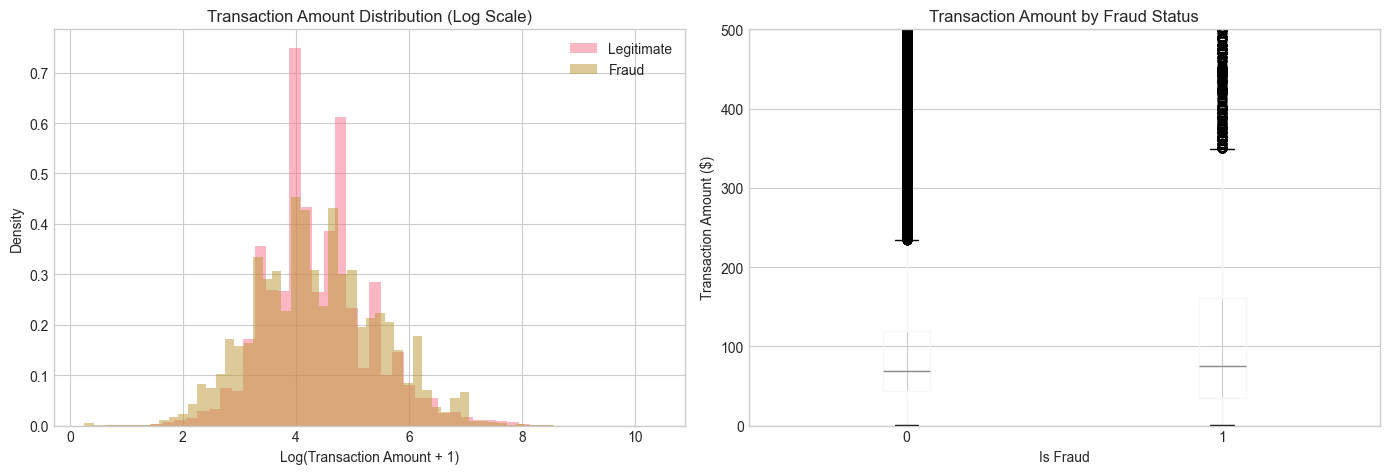

In [14]:
# Transaction amount distribution by fraud status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale histogram
for fraud in [0, 1]:
    subset = train_txn[train_txn['isFraud'] == fraud]['TransactionAmt']
    label = 'Fraud' if fraud else 'Legitimate'
    axes[0].hist(np.log1p(subset), bins=50, alpha=0.5, label=label, density=True)
axes[0].set_xlabel('Log(Transaction Amount + 1)')
axes[0].set_ylabel('Density')
axes[0].set_title('Transaction Amount Distribution (Log Scale)')
axes[0].legend()

# Box plot
train_txn.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1])
axes[1].set_ylim(0, 500)  # Focus on typical range
axes[1].set_xlabel('Is Fraud')
axes[1].set_ylabel('Transaction Amount ($)')
axes[1].set_title('Transaction Amount by Fraud Status')
plt.suptitle('')

plt.tight_layout()
plt.show()

/var/folders/sm/t3nyf7kx5dg_szznqss_p20h0000gn/T/ipykernel_90204/3860070861.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_amt = train_txn.groupby('amt_bucket')['isFraud'].agg(['mean', 'count'])


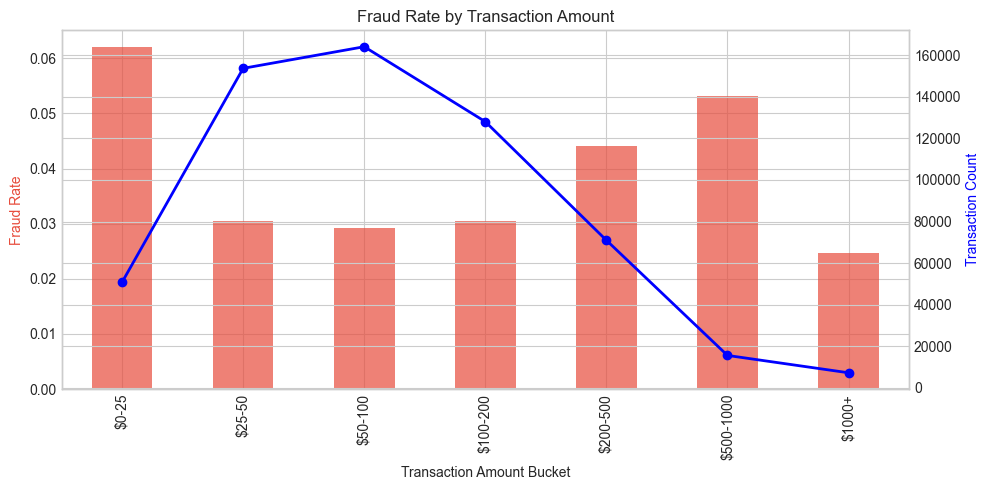

            fraud_rate   count
amt_bucket                    
$0-25         0.061972   50829
$25-50        0.030469  153695
$50-100       0.029178  164095
$100-200      0.030451  128041
$200-500      0.044154   71001
$500-1000     0.053100   15612
$1000+        0.024632    7267


In [15]:
# Fraud rate by amount bucket
train_txn['amt_bucket'] = pd.cut(train_txn['TransactionAmt'], 
                             bins=[0, 25, 50, 100, 200, 500, 1000, float('inf')],
                             labels=['$0-25', '$25-50', '$50-100', '$100-200', '$200-500', '$500-1000', '$1000+'])

fraud_by_amt = train_txn.groupby('amt_bucket')['isFraud'].agg(['mean', 'count'])
fraud_by_amt.columns = ['fraud_rate', 'count']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

fraud_by_amt['fraud_rate'].plot(kind='bar', ax=ax1, color='#e74c3c', alpha=0.7)
ax2.plot(range(len(fraud_by_amt)), fraud_by_amt['count'], 'b-o', linewidth=2)

ax1.set_xlabel('Transaction Amount Bucket')
ax1.set_ylabel('Fraud Rate', color='#e74c3c')
ax2.set_ylabel('Transaction Count', color='blue')
ax1.set_title('Fraud Rate by Transaction Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(fraud_by_amt)

## 5. Time-Based Patterns

In [16]:
timestamp_days = train_txn['TransactionDT'] // 86400
print(f"Time span: {timestamp_days.max() - timestamp_days.min()} days")

Time span: 181 days


In [17]:
# TransactionDT is seconds from an unknown reference point
# We can detect cyclical patterns but can't know the actual hour/day

# Extract raw cyclical values (local variables for EDA)
# Since the span is 181 days, less than a year, we won't bother with
# an annual cycle
hour = (train_txn['TransactionDT'] / 3600) % 24
day = (train_txn['TransactionDT'] / 86400) % 7

train_txn['hod'] = hour  # hour of day
train_txn['dow'] = day   # day of week

# Sine/cosine encoding for cyclical features (hour of day and day of week)
# This ensures hour 23 and hour 0 are neighbors
train_txn['hod_sin'] = np.sin(2 * np.pi * hour / 24)
train_txn['hod_cos'] = np.cos(2 * np.pi * hour / 24)

train_txn['dow_sin'] = np.sin(2 * np.pi * day / 7)
train_txn['dow_cos'] = np.cos(2 * np.pi * day / 7)

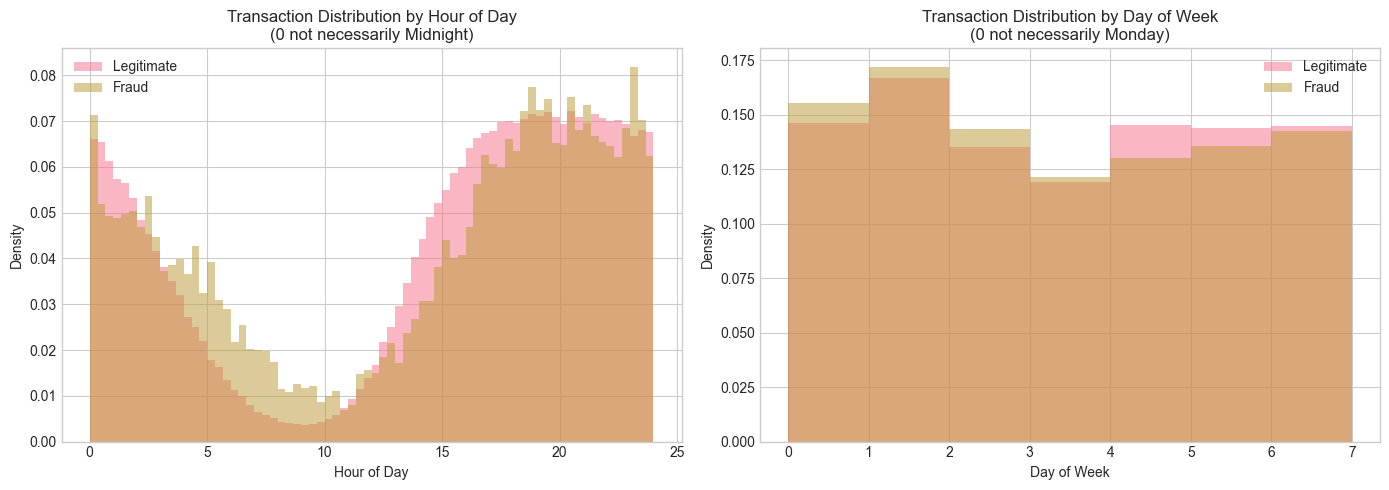

In [18]:
# Fraud vs. Non-fraud for time of day and day of week

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hour of day histogram
for fraud in [0, 1]:
    subset = train_txn[train_txn['isFraud'] == fraud]['hod']
    label = 'Fraud' if fraud else 'Legitimate'
    axes[0].hist(subset, bins=24*3, alpha=0.5, label=label, density=True)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Density')
axes[0].set_title('Transaction Distribution by Hour of Day\n(0 not necessarily Midnight)')
axes[0].legend()

# Day of week histogram
for fraud in [0, 1]:
    subset = train_txn[train_txn['isFraud'] == fraud]['dow']
    label = 'Fraud' if fraud else 'Legitimate'
    axes[1].hist(subset, bins=7, alpha=0.5, label=label, density=True)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Density')
axes[1].set_title('Transaction Distribution by Day of Week\n(0 not necessarily Monday)')
axes[1].legend()

plt.tight_layout()
plt.show()

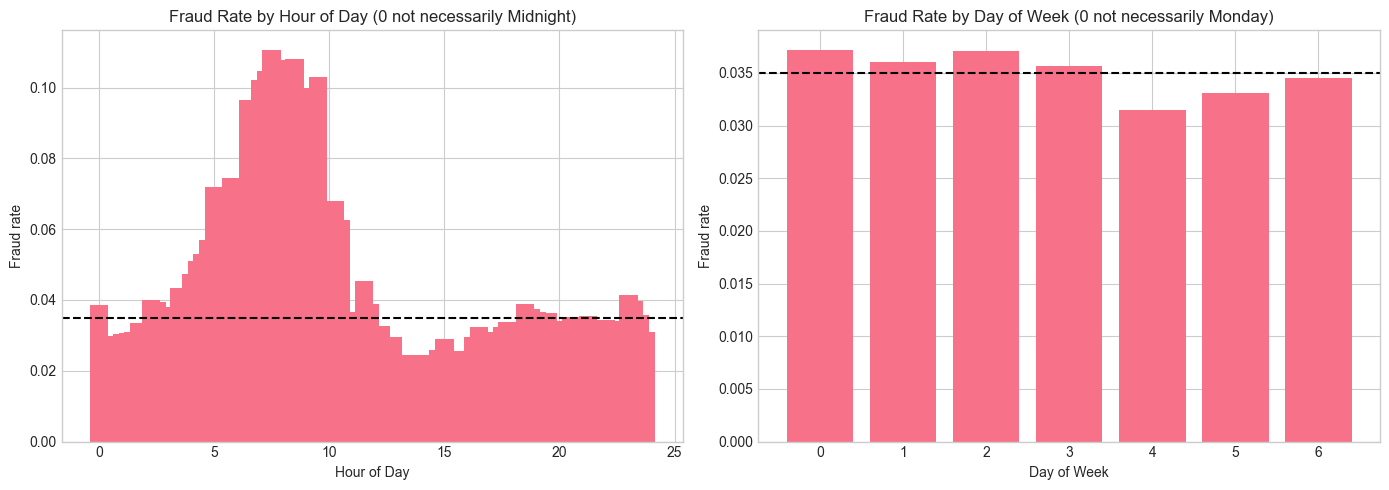

In [19]:
# Fraud rate by hour and day
fraud_rate = train_txn['isFraud'].mean()

def bin_fraud_rates(dataframe: pd.DataFrame, col: str, nbins: int = 24):
    bins = np.linspace(
        np.floor(dataframe[col].min()),
        np.ceil(dataframe[col].max()),
        nbins+1
        )
    rates = []
    for i in range(nbins):
        _series = train_txn[
            (dataframe[col] >= bins[i]) & (dataframe[col] < bins[i+1])
        ]['isFraud']
        rates.append([bins[i], _series.mean()])
    return np.array(rates)

# Create a histogram by binning the hours of the day and calculating the fraud 
# rate in each bin

hod_rates = bin_fraud_rates(train_txn, 'hod', 24*4)
dow_rates = bin_fraud_rates(train_txn, 'dow', 7)

# Plot the histogram, including h line for overall rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(hod_rates[:, 0], hod_rates[:, 1])
axes[0].axhline(
    y=fraud_rate, 
    color='black', 
    linestyle='--', 
    label=f'Overall: {fraud_rate:.2%}'
)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud rate')
axes[0].set_title('Fraud Rate by Hour of Day (0 not necessarily Midnight)')

axes[1].bar(dow_rates[:, 0], dow_rates[:, 1])
axes[1].axhline(
    y=fraud_rate, 
    color='black', 
    linestyle='--', 
    label=f'Overall: {fraud_rate:.2%}'
)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fraud rate')
axes[1].set_title('Fraud Rate by Day of Week (0 not necessarily Monday)')
plt.tight_layout()
plt.show()

## 6. Card Features Analysis

In [37]:
col = "card4"

fraud_by_card = train_txn.groupby(col)['isFraud'].agg(['mean', 'sum', 'count'])
# fraud_by_card = fraud_by_card[fraud_by_card['count'] > 1000]

In [38]:
fraud_by_card

,mean,sum,count
card4,,,
american express,0.028698,239,8328
discover,0.077282,514,6651
mastercard,0.034331,6496,189217
visa,0.034756,13373,384767


In [39]:
fraud_by_card = fraud_by_card[fraud_by_card['count'] > 1000].sort_values(by="mean")

In [40]:
fraud_by_card

,mean,sum,count
card4,,,
american express,0.028698,239,8328
mastercard,0.034331,6496,189217
visa,0.034756,13373,384767
discover,0.077282,514,6651


In [107]:
n = 12736346183416
s = str(n)

len(s)

14

In [109]:
chunks = []
i = len(s) - 3
while i >= -2:
    print(i)
    chunks.append(s[i:i+3])
    i -= 3
    
chunks

11
8
5
2
-1


['416', '183', '346', '736', '']

In [112]:
s[:14%3]

'12'

In [99]:
list(range(14%3, 14, 3))

[2, 5, 8, 11]

In [126]:
n = 1200001
s = str(n)
",".join([s[:len(s)%3]]+[s[i:i+3] for i in range(len(s)%3, len(s), 3)]).strip(',')

'1,200,001'

In [104]:
fraud_by_card.apply(lambda x: f"{x['sum']:.0f} of {x['count']:.0f}", axis=1).to_list()

['10674 of 439938', '9950 of 148986']

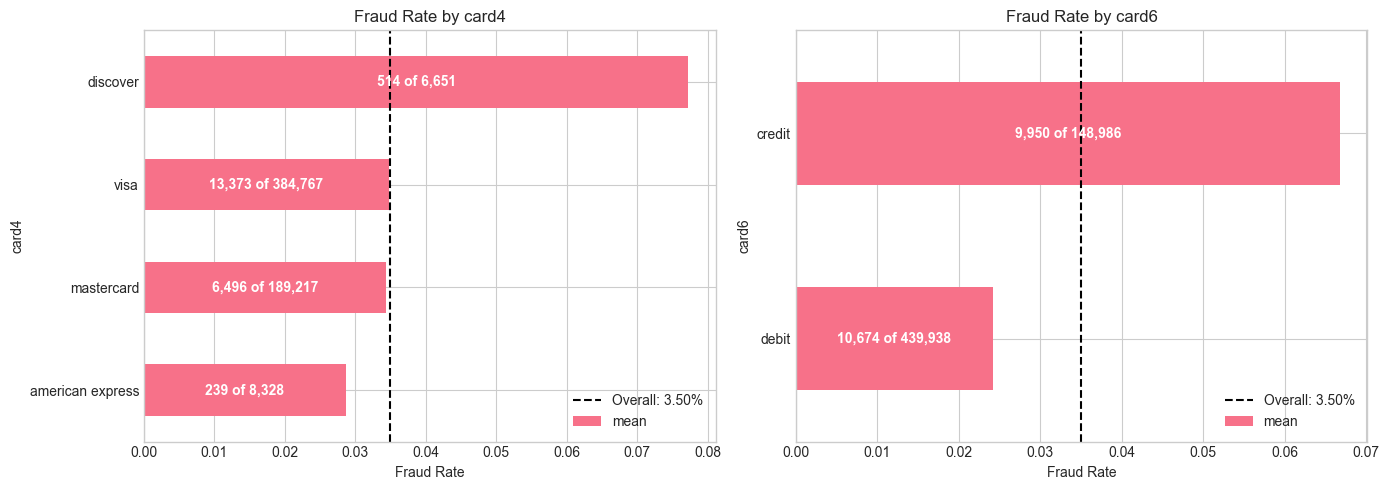

In [128]:
# Fraud rate by card type (card4) and category (card6)
fraud_rate = train_txn['isFraud'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def format_big_int(n: int) -> str:
    s = str(int(n))
    return ",".join([s[:len(s)%3]]+[s[i:i+3] for i in range(len(s)%3, len(s), 3)]).strip(',')
        
for ax, col in zip(axes, ['card4', 'card6']):
    fraud_by_card = train_txn.groupby(col)['isFraud'].agg(['mean', 'sum', 'count'])
    fraud_by_card = fraud_by_card[fraud_by_card['count'] > 1000].sort_values(by='mean')  # Filter for significance
    fraud_by_card['mean'].plot(kind='barh', ax=ax)
    
    # Add annotations inside each bar
    for container in ax.containers:
        labels = fraud_by_card.apply(lambda x: f"{format_big_int(x['sum'])} of {format_big_int(x['count'])}", axis=1).to_list()
        ax.bar_label(container, labels=labels, label_type='center', 
                     fontsize=10, color='white', fontweight='bold')
    
    ax.set_xlabel('Fraud Rate')
    ax.set_title(f'Fraud Rate by {col}')
    ax.axvline(x=fraud_rate, color='black', linestyle='--', label=f'Overall: {fraud_rate:.2%}')
    ax.legend()

fig.tight_layout()
fig.savefig(FIG_DIR / 'EDA_fraud_by_card.png')
plt.show()

## 7. Product Code Analysis

Fraud rate by Product Code:
           fraud_rate   count  avg_amount
ProductCD                                
C              0.1169   68519     42.8724
S              0.0590   11628     60.2695
H              0.0477   33024     73.1701
R              0.0378   37699    168.3062
W              0.0204  439670    153.1586


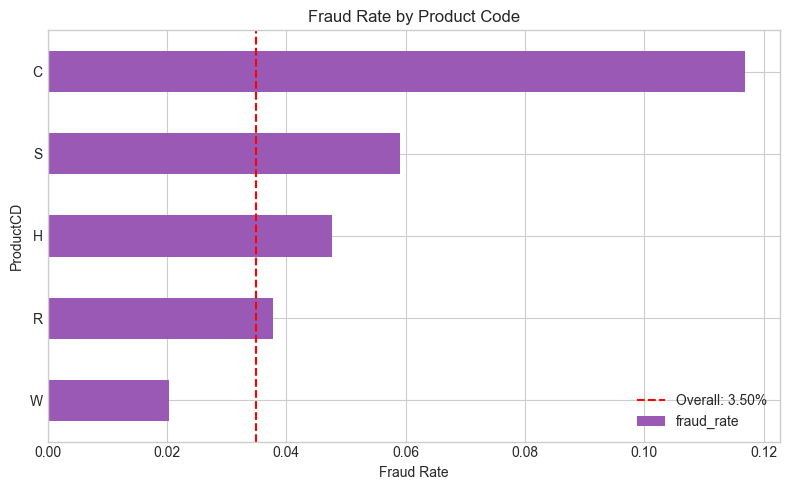

In [56]:
# ProductCD analysis
fraud_rate = train_txn['isFraud'].mean()

product_fraud = train_txn.groupby('ProductCD').agg(
    fraud_rate=('isFraud', 'mean'),
    count=('isFraud', 'count'),
    avg_amount=('TransactionAmt', 'mean')
).round(4)

print("Fraud rate by Product Code:")
print(product_fraud.sort_values('fraud_rate', ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
product_fraud['fraud_rate'].sort_values().plot(kind='barh', ax=ax, color='#9b59b6')
ax.set_xlabel('Fraud Rate')
ax.set_title('Fraud Rate by Product Code')
ax.axvline(x=fraud_rate, color='red', linestyle='--', label=f'Overall: {fraud_rate:.2%}')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Email Domain Analysis

In [57]:
# Email domains
for col in ['P_emaildomain', 'R_emaildomain']:
    print(f"\n{col}:")
    print(f"  Missing: {train_txn[col].isnull().sum() / len(train_txn):.2%}")
    
    # Top domains by fraud rate
    domain_fraud = train_txn.groupby(col)['isFraud'].agg(['mean', 'count'])
    domain_fraud = domain_fraud[domain_fraud['count'] > 1000]
    print(f"\n  Highest fraud rate domains:")
    print(domain_fraud.nlargest(5, 'mean'))


P_emaildomain:
  Missing: 15.99%

  Highest fraud rate domains:
                   mean   count
P_emaildomain                  
outlook.com    0.094584    5096
hotmail.com    0.052950   45250
gmail.com      0.043542  228355
icloud.com     0.031434    6267
comcast.net    0.031187    7888

R_emaildomain:
  Missing: 76.75%

  Highest fraud rate domains:
                   mean  count
R_emaildomain                 
outlook.com    0.165138   2507
icloud.com     0.128755   1398
gmail.com      0.119184  57147
hotmail.com    0.077793  27509
yahoo.com      0.051512  11842


In [58]:
# Email domain match
train_txn['email_match'] = train_txn['P_emaildomain'] == train_txn['R_emaildomain']
email_match_fraud = train_txn.groupby('email_match')['isFraud'].mean()
print("Fraud rate by email domain match:")
print(email_match_fraud)

Fraud rate by email domain match:
email_match
False    0.022070
True     0.096504
Name: isFraud, dtype: float64


## 9. Device and Identity Features

In [59]:
# Identity data availability
identity_fraud = train_txn.groupby('hasID')['isFraud'].mean()
print("Fraud rate by identity data availability:")
print(identity_fraud)
print(f"\nTransactions with identity data: {train_txn['hasID'].mean():.2%}")

Fraud rate by identity data availability:
hasID
False    0.020939
True     0.078470
Name: isFraud, dtype: float64

Transactions with identity data: 24.42%


In [164]:
def format_big_int(n: int) -> str:
    s = str(int(n))
    return ",".join([s[:len(s)%3]]+[s[i:i+3] for i in range(len(s)%3, len(s), 3)]).strip(',')
    

def fraud_rate_analysis(dataframe: pd.DataFrame, column: str, cutoff: int = 500):
    """Prints a tabulated summary of the given column."""
    gb = dataframe.groupby(column)['isFraud'].agg(
            ['count', 'sum', 'mean']
        ).sort_values(
            by='mean', ascending=False
        ).reset_index()
        
    gb = gb[gb['count'] >= cutoff].copy()
    
    gb['mean'] = gb['mean'].apply(lambda x: f"{x * 100:.1f}%")
    gb['sum'] = gb['sum'].apply(format_big_int)
    gb['count'] = gb['count'].apply(format_big_int)
    
    gb.rename(
        columns={"mean": "Fraud Rate", "sum": "Frauds", "count": "Transactions"}, 
        inplace=True
        )
    
    table = tabulate(
        tabular_data=gb, 
        headers="keys", 
        showindex=False, 
        tablefmt='fancy_grid',
        colalign=("left", "right", "right", "right")
        )
    
    print(table)

In [167]:
# Device type analysis
print("\nFraud rate by device type:")
fraud_rate_analysis(train_id, 'DeviceType')


Fraud rate by device type:
╒══════════════╤════════════════╤══════════╤══════════════╕
│ DeviceType   │   Transactions │   Frauds │   Fraud Rate │
╞══════════════╪════════════════╪══════════╪══════════════╡
│ mobile       │         55,645 │    5,657 │        10.2% │
├──────────────┼────────────────┼──────────┼──────────────┤
│ desktop      │         85,165 │    5,554 │         6.5% │
╘══════════════╧════════════════╧══════════╧══════════════╛


In [166]:
# Browser analysis (top browsers)
if 'DeviceInfo' in train_id.columns:
    print("\nHighest fraud rate devices:")
    fraud_rate_analysis(train_id, 'DeviceInfo')


Highest fraud rate devices:
╒═══════════════════════╤════════════════╤══════════╤══════════════╕
│ DeviceInfo            │   Transactions │   Frauds │   Fraud Rate │
╞═══════════════════════╪════════════════╪══════════╪══════════════╡
│ SM-J700M Build/MMB29K │            549 │       60 │        10.9% │
├───────────────────────┼────────────────┼──────────┼──────────────┤
│ rv:57.0               │            962 │      103 │        10.7% │
├───────────────────────┼────────────────┼──────────┼──────────────┤
│ Windows               │         47,722 │    3,121 │         6.5% │
├───────────────────────┼────────────────┼──────────┼──────────────┤
│ iOS Device            │         19,782 │    1,240 │         6.3% │
├───────────────────────┼────────────────┼──────────┼──────────────┤
│ rv:11.0               │          1,901 │       76 │         4.0% │
├───────────────────────┼────────────────┼──────────┼──────────────┤
│ MacOS                 │         12,573 │      278 │         2.2% │
├────

## 10. V Features (Vesta Engineered Features)

In [62]:
# V features overview
import re
v_cols = [col for col in train_txn.columns if re.match(r'V\d+', col)]
print(f"Number of V features: {len(v_cols)}")

# Missing values in V features
v_missing = train_txn[v_cols].isnull().mean().sort_values(ascending=False)
print(f"\nV features with >50% missing: {(v_missing > 0.5).sum()}")
print(f"V features with <10% missing: {(v_missing < 0.1).sum()}")

Number of V features: 339

V features with >50% missing: 159
V features with <10% missing: 86


Top 20 V features by correlation with fraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64


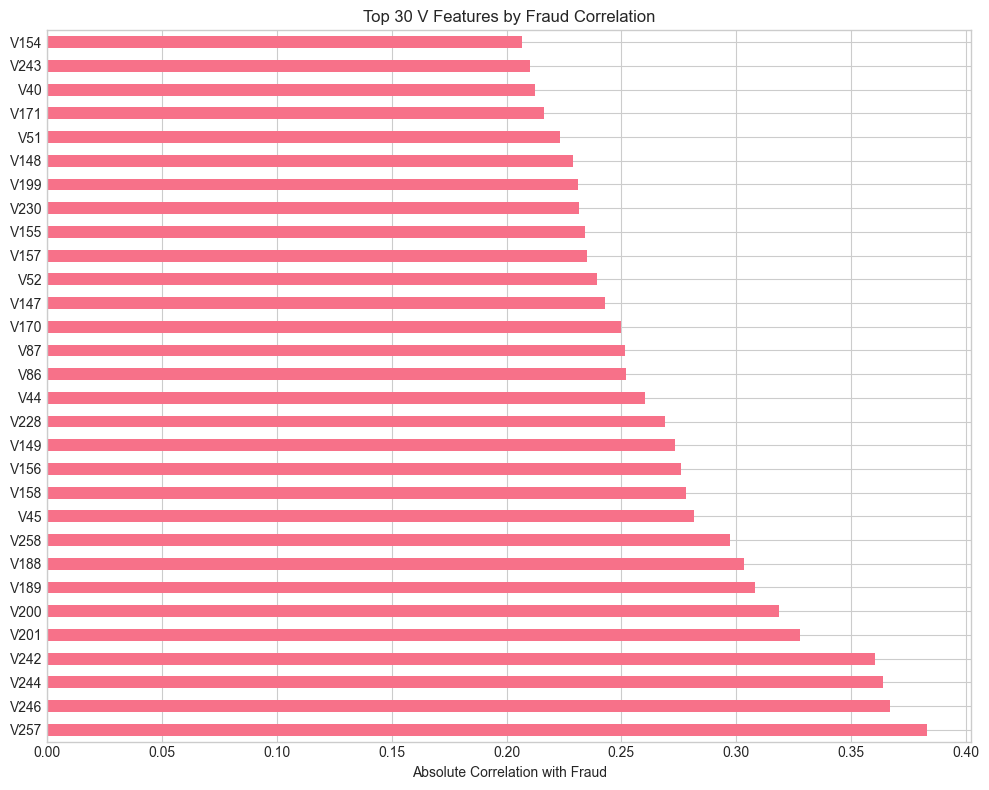

In [24]:
# Correlation of V features with fraud
v_fraud_corr = train_txn[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)

print("Top 20 V features by correlation with fraud:")
print(v_fraud_corr.head(20))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
v_fraud_corr.head(30).plot(kind='barh', ax=ax)
ax.set_xlabel('Absolute Correlation with Fraud')
ax.set_title('Top 30 V Features by Fraud Correlation')
plt.tight_layout()
plt.show()

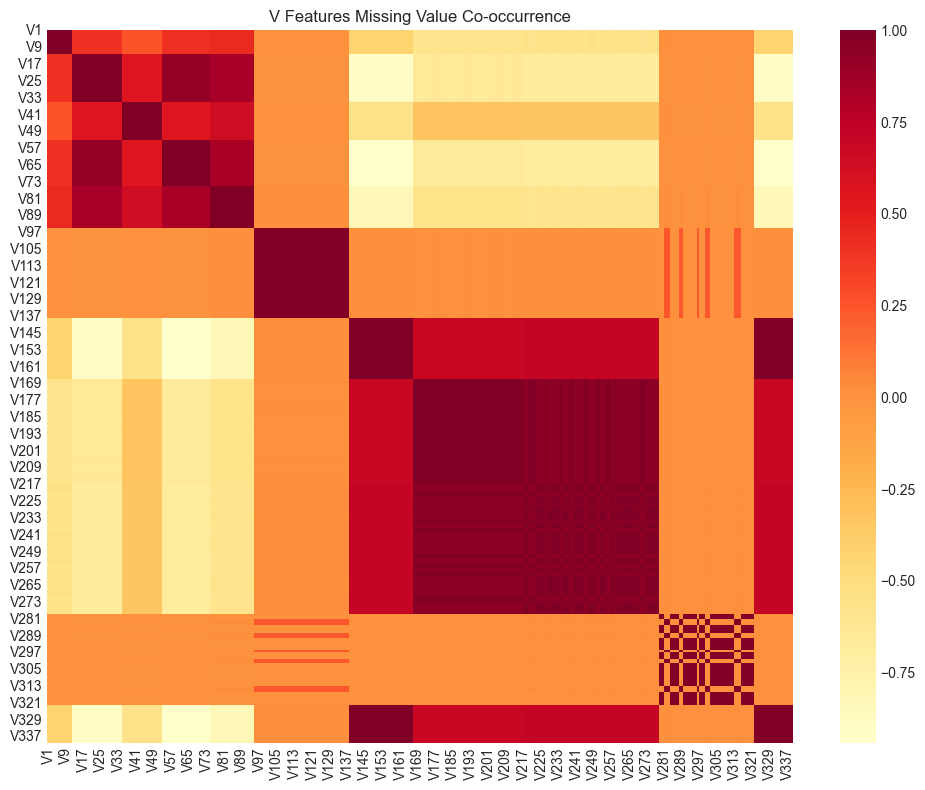

In [26]:
# Missing value co-occurrence
fig, ax = plt.subplots(figsize=(10, 8))
missing_pattern = train_txn[v_cols].isnull().astype(int)
missing_corr = missing_pattern.corr()
sns.heatmap(missing_corr, ax=ax, cmap='YlOrRd', annot=False)
ax.set_title('V Features Missing Value Co-occurrence')

plt.tight_layout()
plt.show()

## 11. C Features (Count Features)

C features correlation with fraud:
C2     0.037229
C8     0.032139
C12    0.031905
C9     0.031703
C5     0.030754
C1     0.030570
C4     0.030382
C10    0.028396
C7     0.028160
C11    0.027484
C6     0.020909
C13    0.011146
C14    0.007921
C3     0.006833
Name: isFraud, dtype: float64


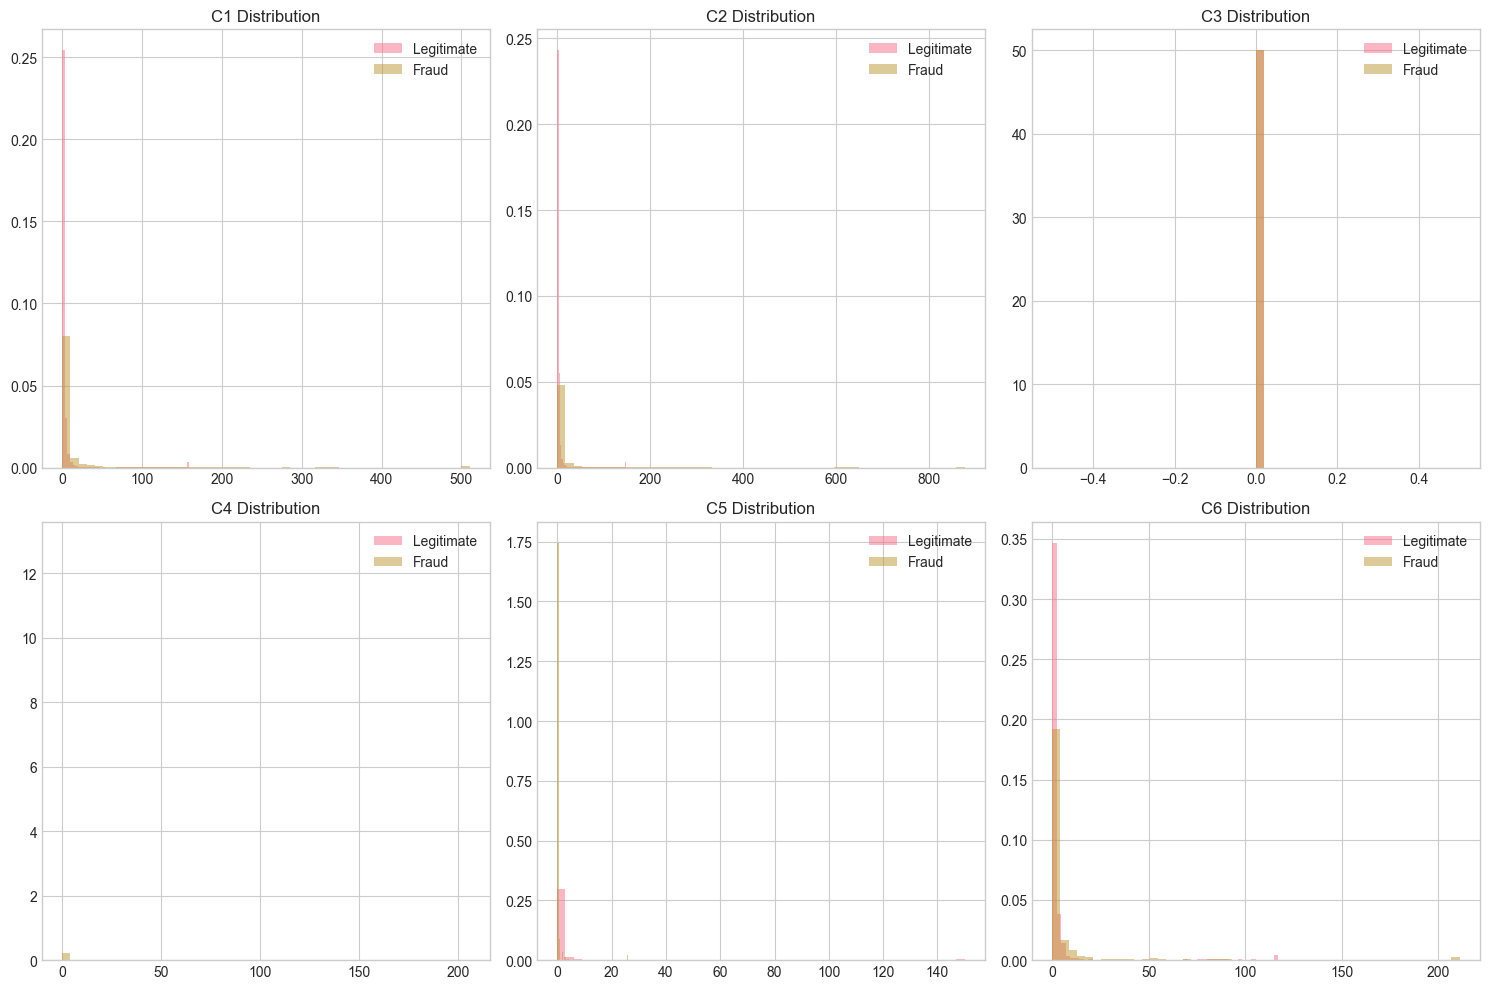

In [63]:
# C features analysis
c_cols = [col for col in train_txn.columns if re.match(r'C\d+', col)]

c_fraud_corr = train_txn[c_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)
print("C features correlation with fraud:")
print(c_fraud_corr)

# Distribution comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, c_cols[:6]):
    for fraud in [0, 1]:
        subset = train_txn[train_txn['isFraud'] == fraud][col].dropna()
        subset_clipped = np.clip(subset, 0, subset.quantile(0.99))
        label = 'Fraud' if fraud else 'Legitimate'
        ax.hist(subset_clipped, bins=50, alpha=0.5, label=label, density=True)
    ax.set_title(f'{col} Distribution')
    ax.legend()
plt.tight_layout()
plt.show()

## 12. D Features (Time Delta Features)

In [64]:
# D features analysis
d_cols = [col for col in train_txn.columns if re.match(r'D\d+', col)]

d_fraud_corr = train_txn[d_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)
print("D features correlation with fraud:")
print(d_fraud_corr)

# Missing pattern
d_missing = train_txn[d_cols].isnull().mean()
print("\nD features missing rates:")
print(d_missing.sort_values(ascending=False))

D features correlation with fraud:
D8     0.142636
D7     0.127199
D2     0.083583
D15    0.077519
D10    0.072002
D4     0.067216
D1     0.067193
D5     0.064638
D13    0.059430
D6     0.057236
D3     0.046271
D11    0.045094
D9     0.044253
D12    0.028864
D14    0.008663
Name: isFraud, dtype: float64

D features missing rates:
D7     0.934099
D13    0.895093
D14    0.894695
D12    0.890410
D6     0.876068
D8     0.873123
D9     0.873123
D5     0.524674
D2     0.475492
D11    0.472935
D3     0.445149
D4     0.286047
D15    0.150901
D10    0.128733
D1     0.002149
dtype: float64


D1 Statistics:
count    589271.000000
mean         94.347568
std         157.660387
min           0.000000
25%           0.000000
50%           3.000000
75%         122.000000
max         640.000000
Name: D1, dtype: float64


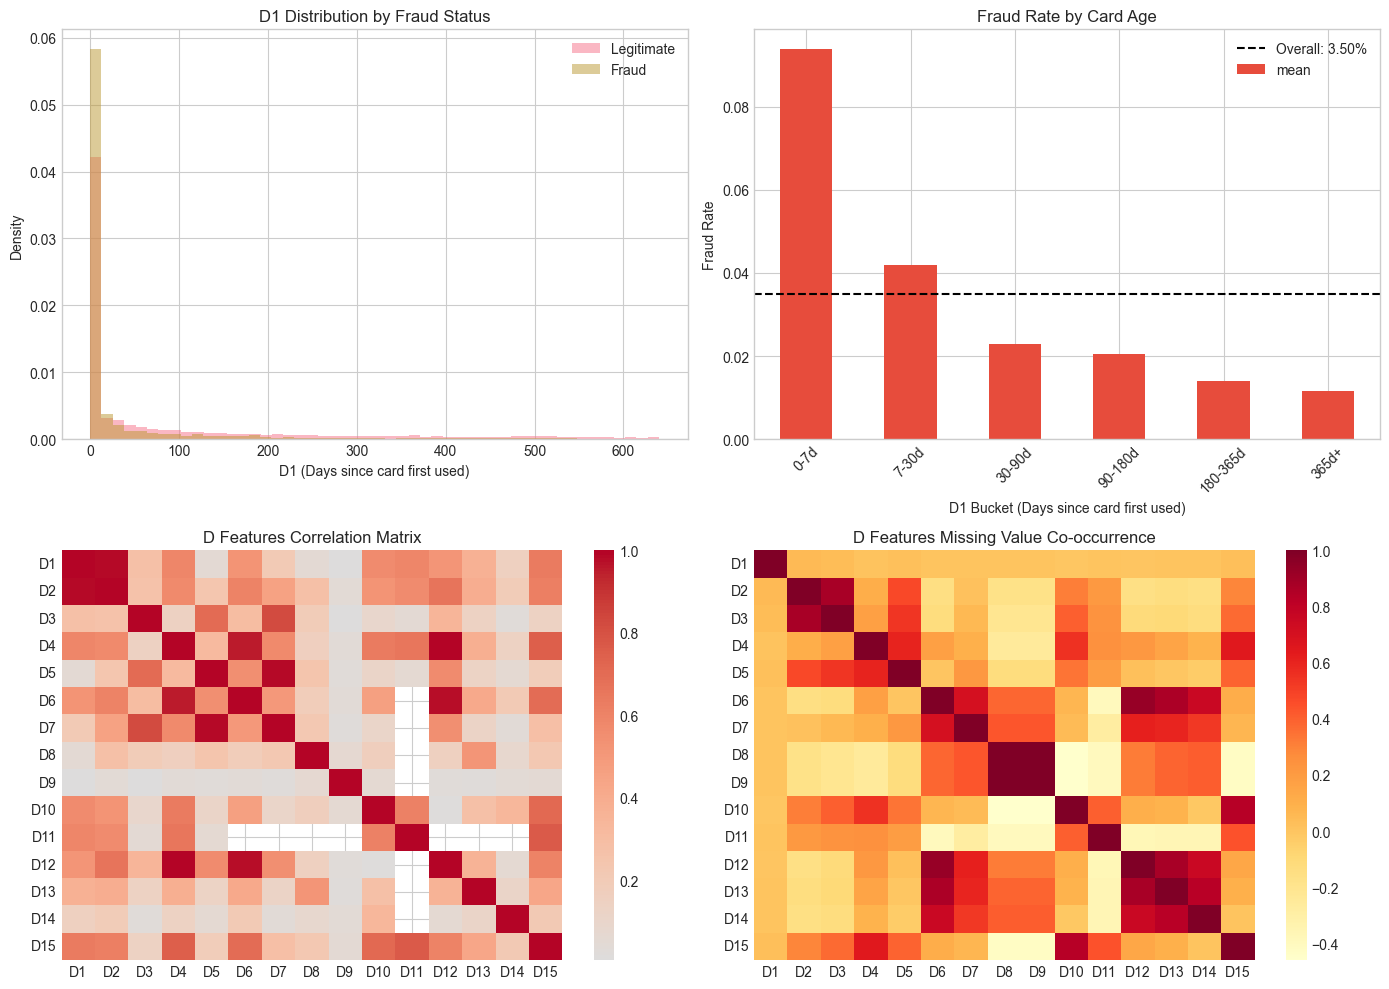


Fraud rate by D1 bucket:
              mean  count
D1                       
0-7d      0.093894  30822
7-30d     0.041808  45422
30-90d    0.022999  63960
90-180d   0.020457  51718
180-365d  0.013956  59188
365d+     0.011718  58031


In [65]:
# Deep dive into D features

# D1 is "days since card was first used" - key for customer identification
print("D1 Statistics:")
print(train_txn['D1'].describe())

# D1 distribution by fraud status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# D1 distribution
ax = axes[0, 0]
for fraud in [0, 1]:
    subset = train_txn[train_txn['isFraud'] == fraud]['D1'].dropna()
    label = 'Fraud' if fraud else 'Legitimate'
    ax.hist(subset, bins=50, alpha=0.5, label=label, density=True)
ax.set_xlabel('D1 (Days since card first used)')
ax.set_ylabel('Density')
ax.set_title('D1 Distribution by Fraud Status')
ax.legend()

# Fraud rate by D1 buckets
ax = axes[0, 1]
d1_buckets = pd.cut(train_txn['D1'], bins=[0, 7, 30, 90, 180, 365, float('inf')],
                    labels=['0-7d', '7-30d', '30-90d', '90-180d', '180-365d', '365d+'])
fraud_by_d1 = train_txn.groupby(d1_buckets, observed=False)['isFraud'].agg(['mean', 'count'])
fraud_by_d1['mean'].plot(kind='bar', ax=ax, color='#e74c3c')
ax.set_xlabel('D1 Bucket (Days since card first used)')
ax.set_ylabel('Fraud Rate')
ax.set_title('Fraud Rate by Card Age')
ax.axhline(y=fraud_rate, color='black', linestyle='--', label=f'Overall: {fraud_rate:.2%}')
ax.legend()
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# D columns correlation heatmap
ax = axes[1, 0]
d_corr = train_txn[d_cols].corr()
sns.heatmap(d_corr, ax=ax, cmap='coolwarm', center=0, annot=False)
ax.set_title('D Features Correlation Matrix')

# Missing value co-occurrence
ax = axes[1, 1]
d_missing_pattern = train_txn[d_cols].isnull().astype(int)
missing_corr = d_missing_pattern.corr()
sns.heatmap(missing_corr, ax=ax, cmap='YlOrRd', annot=False)
ax.set_title('D Features Missing Value Co-occurrence')

plt.tight_layout()
plt.show()

# Key insight: New cards (low D1) have higher fraud rate
print("\nFraud rate by D1 bucket:")
print(fraud_by_d1)

## Key Insights Summary

### Insight 1: Class Imbalance
- Fraud rate is ~3.5%, requiring careful handling of class imbalance (stratified splits, class weights, or oversampling)

### Insight 2: Transaction Amount Patterns
- Fraud transactions have slightly higher mean amount ($149 vs $135)
- Fraud rate increases with transaction amount: 2.4% for $0-25 → 5.5% for $500-1000
- However, very high amounts ($1000+) drop back to 3.4% — consider bucketing for feature engineering

### Insight 3: Time-Based Patterns
- Clear cyclical patterns in hour-of-day fraud rates
- Use sine/cosine encoding for time features to capture cyclical nature
- Day-of-week also shows variation but less pronounced

### Insight 4: Card Type Risk
- **card4**: Discover has 2.3x higher fraud rate (7.7%) vs other cards (~3%)
- **card6**: Debit cards show higher fraud rate than credit cards
- Card network is a strong categorical predictor

### Insight 5: Product Code Risk
- Product C has the highest fraud rate among product codes
- Product code should be one-hot encoded or target-encoded

### Insight 6: Device & Identity Patterns
- Mobile devices show 10.2% fraud rate vs 6.5% for desktop (1.6x higher)
- Transactions WITH identity data have higher fraud rate (7.8%) than those without (2.1%)
- Counterintuitive: presence of identity data correlates with fraud — suggests identity info is logged when fraud detection triggers
- Email domain match (P=R) shows 9.7% fraud rate vs 2.2% when different

### Insight 7: V Features Value
- 339 V features with varying missing rates (159 have >50% missing)
- Top correlated V features: V258, V317, V294 show strongest fraud correlation
- Missing value patterns are highly correlated — suggests grouped collection (V1-V11, V12-V34, etc.)
- Use correlation-based feature selection or PCA to reduce dimensionality

### Insight 8: D Features (Time Deltas)
- D8 and D7 show strongest fraud correlation (0.14, 0.13)
- New cards (D1 < 7 days) have elevated fraud rates
- D features have high missing rates (up to 93%) — missing pattern itself may be predictive